# Final Project

In [1]:
!pip install sep
!pip install astropy

In [2]:
import numpy as np
import sep

In [3]:

!pip install astropy

# After installation completes, restart the kernel
# Go to Kernel menu -> Restart

# After restarting the kernel, run this cell to import the libraries
from astropy.io import fits  # Use this instead of fitsio
import matplotlib.pyplot as plt
from matplotlib import rcParams

%matplotlib inline

rcParams['figure.figsize'] = [10., 8.]

# Note: You may need to adjust your code that uses fitsio functions
# as the astropy.io.fits API might be slightly different

In [4]:
# read image into standard 2-d numpy array
from astropy.io import fits
data = fits.getdata("hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits")

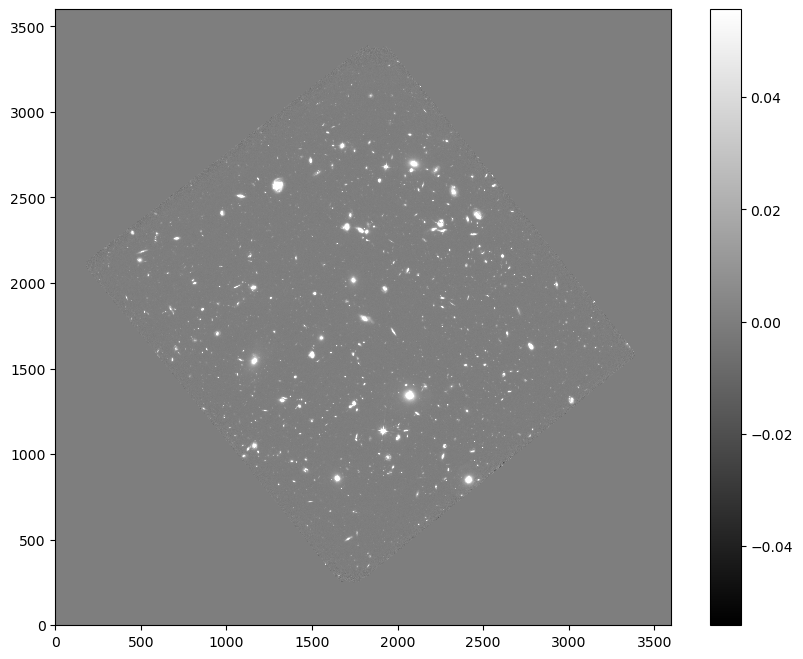

In [5]:
m, s = np.mean(data), np.std(data)
plt.imshow(data, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar();

# Background Subtraction

In [25]:
data = data.astype(data.dtype.newbyteorder('='))
bkg = sep.Background(data, mask=None, bw=64, bh=64, fw=3, fh=3)


In [26]:
print(bkg.globalback)
print(bkg.globalrms)

0.0
0.0005398219218477607


In [27]:
# evaluate background as 2-d array, same size as original image
bkg_image = bkg.back()


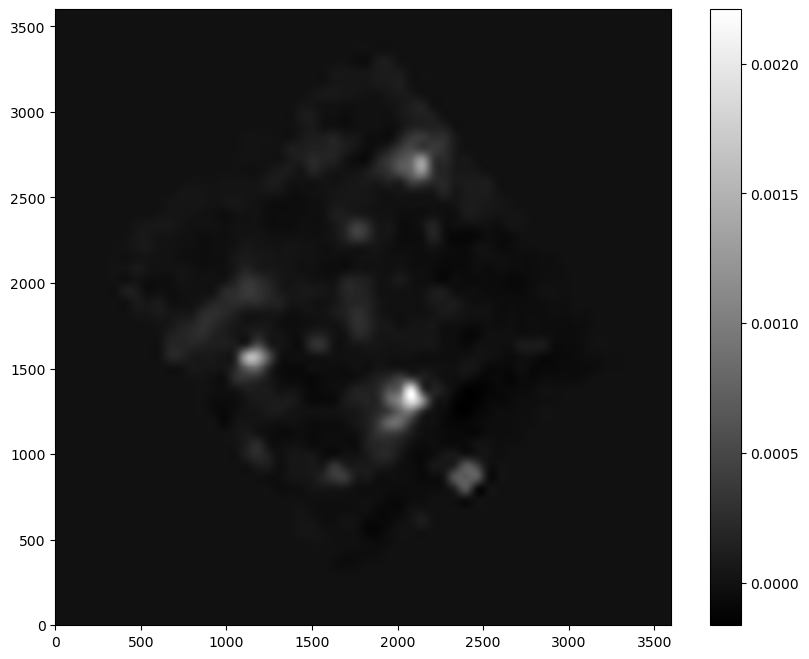

In [28]:
# show the background
plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();

In [29]:
# evaluate the background noise as 2-d array, same size as original image
bkg_rms = bkg.rms()

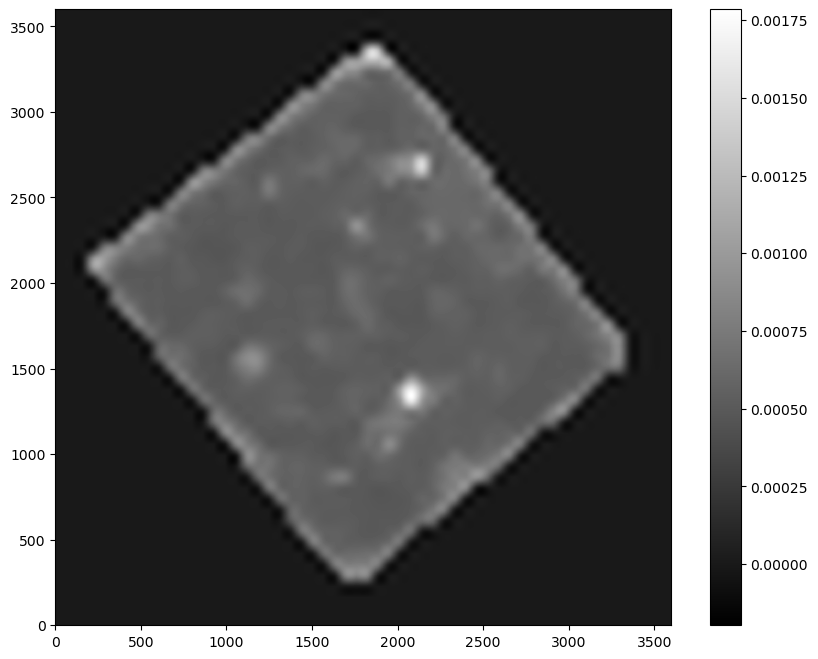

In [30]:
# show the background noise
plt.imshow(bkg_rms, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();

In [31]:
# subtract the background
data_sub = data - bkg


# Object Detection

In [62]:
objects = sep.extract(data_sub, 8, err=bkg.globalrms)

In [63]:
# how many objects were detected
len(objects)

1822

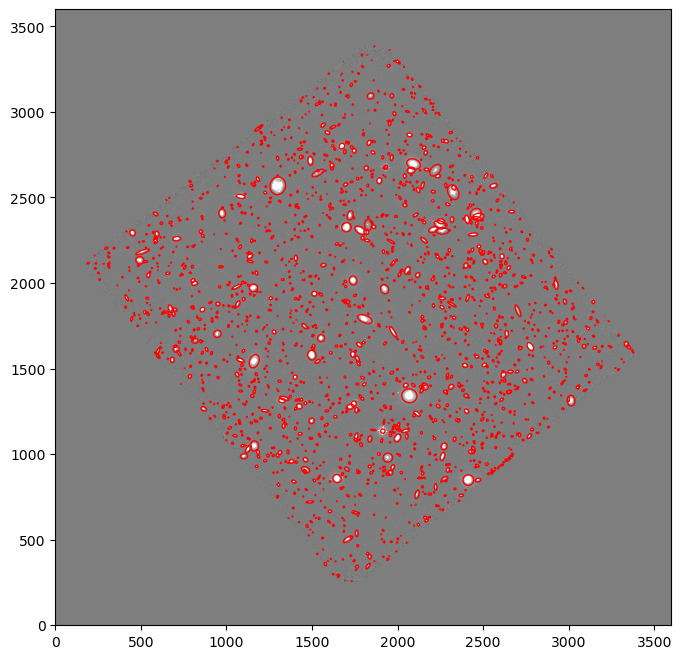

In [64]:
from matplotlib.patches import Ellipse

# plot background-subtracted image
fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m-s, vmax=m+s, origin='lower')

# plot an ellipse for each object
for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=6*objects['a'][i],
                height=6*objects['b'][i],
                angle=objects['theta'][i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)

# Aperture Photometry

In [65]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'], 3.0, err=bkg.globalrms, gain=1.0)


In [66]:
# show the first 10 objects results:
for i in range(10):
    print("object {:d}: flux = {:f} +/- {:f}".format(i, flux[i], fluxerr[i]))

object 0: flux = 0.105546 +/- 0.324891
object 1: flux = 0.068334 +/- 0.261423
object 2: flux = 0.142847 +/- 0.377962
object 3: flux = 1.152321 +/- 1.073466
object 4: flux = 0.147404 +/- 0.383943
object 5: flux = 0.137031 +/- 0.370188
object 6: flux = 0.108634 +/- 0.329609
object 7: flux = 0.556304 +/- 0.745863
object 8: flux = 1.124687 +/- 1.060517
object 9: flux = 0.847740 +/- 0.920732


# Questions

1) How many sources (stars) do you find in the data? Histogram their fluxes.

In [67]:
print("I found", len(objects), "stars")

I found 1822 stars


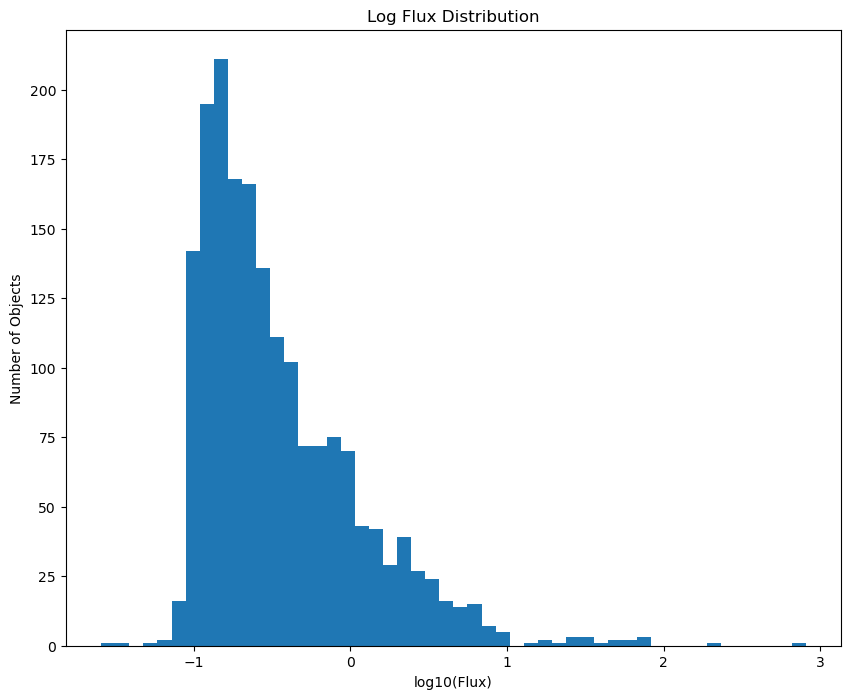

In [69]:
plt.hist(np.log10(flux[flux > 0]), bins=50)

plt.xlabel("log10(Flux)")
plt.ylabel("Number of Objects")
plt.title("Log Flux Distribution")

plt.show()

2) What are the mean, median, and standard deviation of the distribution of fluxes.

In [71]:
mean_flux = np.mean(flux)
median_flux = np.median(flux)
std_flux = np.std(flux)
print("Mean:", mean_flux)
print("Median:", median_flux)
print("Std Dev:", std_flux)

Mean: 1.625903247400226
Median: 0.25293306278530514
Std Dev: 20.04289833432188


3) What is the largest outlier in the distribution; how many standard deviations is it away from the mean?

In [72]:
max_flux = np.max(flux)
z_score = (max_flux - mean_flux) / std_flux
print("Largest flux:", max_flux)
print("Z-score:", z_score)

Largest flux: 805.4553882980348
Z-score: 40.10545139941863
